<h1 style="color: #CEDDF4;">DEPI Round 4, MS Data Engineer and AI Track</h1>
<h2 style="color: #CEDDF4;" >Final Project: Gold and Oil Prediction System</h2>
<h3 style="color: #CEDDF4;" > Part (2): Python Code for Machine Learning and Modeling</h3>

<h4 style="color: #CEDDF4;" >1. Import Libraries</h4>

In [1]:
import pandas as pd
import numpy as np
import math
from pathlib import Path
import os
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,precision_score
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics
import xgboost as xgb
from xgboost import XGBClassifier,XGBRegressor
import joblib
from sklearn.preprocessing import StandardScaler
from functools import reduce
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestClassifier

In [2]:
base_dir = Path.cwd()
#raw data path to contain all raw files gathered either manually, web scraping or APIs
raw_data_dir=base_dir/'raw data'
#cleaned data path, will be separated into two main folders which are: market data (contains the data with daily logs) and macroeconomic data
##cleaned market data
cleaned_market_data_dir=base_dir/'cleaned data'/'market_data'
##cleaned macroeconomic data
cleaned_macro_data_dir=base_dir/'cleaned data'/'macroeconomic_data'
##ai modeling data
ai_data_dir=base_dir/'ai model'

<h4 style="color: #CEDDF4;" >1. Data Loading and Processing</h4>

In [3]:
def make_tag(filename):
    tag = filename
    tag = tag.replace('global_', '').replace('usa_', '').replace('egy_', '')
    tag = tag.replace('_prices', '').replace('_price', '').replace('_index', '').replace('_rate', '')
    return tag

In [4]:
#the below function is made to call all the date within specific folder (market / macro) and make final cleaning and sorting methods on it to be using in our master table
def loading(filename, tag, dir):
    df = pd.read_csv(dir / f"{filename}.csv")
    df = df.drop(columns=['id', 'region', 'ticker'], errors='ignore')
    df['date'] = pd.to_datetime(df['date'], dayfirst=True, format='mixed', errors='coerce')
    df = df.rename(columns={c: f"{tag}_{c}" for c in df.columns if c != 'date'})
    df = df.drop_duplicates(subset='date')
    df = df.set_index('date')
    full_dates = pd.date_range(start='2016-01-01', end='2026-03-29', freq='D')
    df = df.reindex(full_dates)
    first_valid = df.first_valid_index()
    if first_valid is not None:
        df.loc[:first_valid] = df.loc[:first_valid].bfill()
    df = df.ffill()
    df = df.reset_index().rename(columns={'index': 'date'})
    return df

In [5]:
#the below is for loop to iterate over all files within cleaned market data 
all_market_df=[]
for filepath in cleaned_market_data_dir.glob("*.csv"):
    raw_file_name = filepath.stem
    tag = make_tag(raw_file_name)
    new_df = loading(raw_file_name, tag, cleaned_market_data_dir)
    all_market_df.append(new_df)

In [6]:
#the below is a minor tweak to egy_cpi file in macroeconomic data folder which is obtained via data_cleaning.ipynb section 2.1
egy_cpi=pd.read_csv(cleaned_macro_data_dir/'egy_cpi.csv')
egy_cpi=egy_cpi.rename(columns={'year':'date'})
egy_cpi.to_csv(cleaned_macro_data_dir/'egy_cpi.csv')

In [8]:
#the below is for loop to iterate over all files within cleaned macroeconomic data data 
all_macro_df=[]
for filepath in cleaned_macro_data_dir.glob("*.csv"):
    raw_file_name = filepath.stem
    tag = make_tag(raw_file_name)
    new_df = loading(raw_file_name, tag, cleaned_macro_data_dir)
    all_macro_df.append(new_df)

KeyError: 'date'

In [ ]:
#get all dataframes from previous steps in one dataframe as reduce function takes only one argument
all_df = all_macro_df + all_market_df
#create the master table and make data column the primary key for merging process
master_table = reduce(lambda left, right: pd.merge(left, right, on='date', how='outer'), all_df)
master_table = master_table.dropna(axis=1, how='all')

In [ ]:
#saving the master table into a csv file to be used in the modeling
master_table.to_csv(ai_data_dir/'master_table.csv')

In [ ]:
df=pd.read_csv(ai_data_dir/'master_table.csv')

In [ ]:
df = df.bfill().ffill()

In [ ]:
df.to_csv(ai_data_dir/'new_master_table.csv')

In [ ]:
#only when VS Code crashes
df=pd.read_csv(ai_data_dir/'new_master_table.csv')

In [ ]:
df.shape

(3741, 51)

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3741 entries, 0 to 3740
Data columns (total 51 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Unnamed: 0.1                 3741 non-null   int64  
 1   Unnamed: 0                   3741 non-null   int64  
 2   date                         3741 non-null   str    
 3   china_gdp_value_usd          3741 non-null   float64
 4   china_ir_value               3741 non-null   float64
 5   euro_inflation_value         3741 non-null   float64
 6   euro_interest_value          3741 non-null   float64
 7   japan_10yy_value             3741 non-null   float64
 8   japan_2yy_value              3741 non-null   float64
 9   japan_cpi_value              3741 non-null   float64
 10  japan_gdp_value              3741 non-null   float64
 11  japan_ir_value               3741 non-null   float64
 12  norway_10yy_value            3741 non-null   float64
 13  norway_2yy_value             

In [ ]:
df['date'] = pd.to_datetime(df['date'], dayfirst=True)
df = df.drop(columns=['gpr_event'], errors='ignore')
data = df[df['date'] <= '2025-08-30'].copy()
f_predict_data = df[(df['date'] >= '2025-09-01') & (df['date'] <= '2025-12-31')].copy()

In [ ]:
describtion_df = data.describe()

In [ ]:
describtion_df.to_csv(ai_data_dir/'stats.csv')

<Axes: >

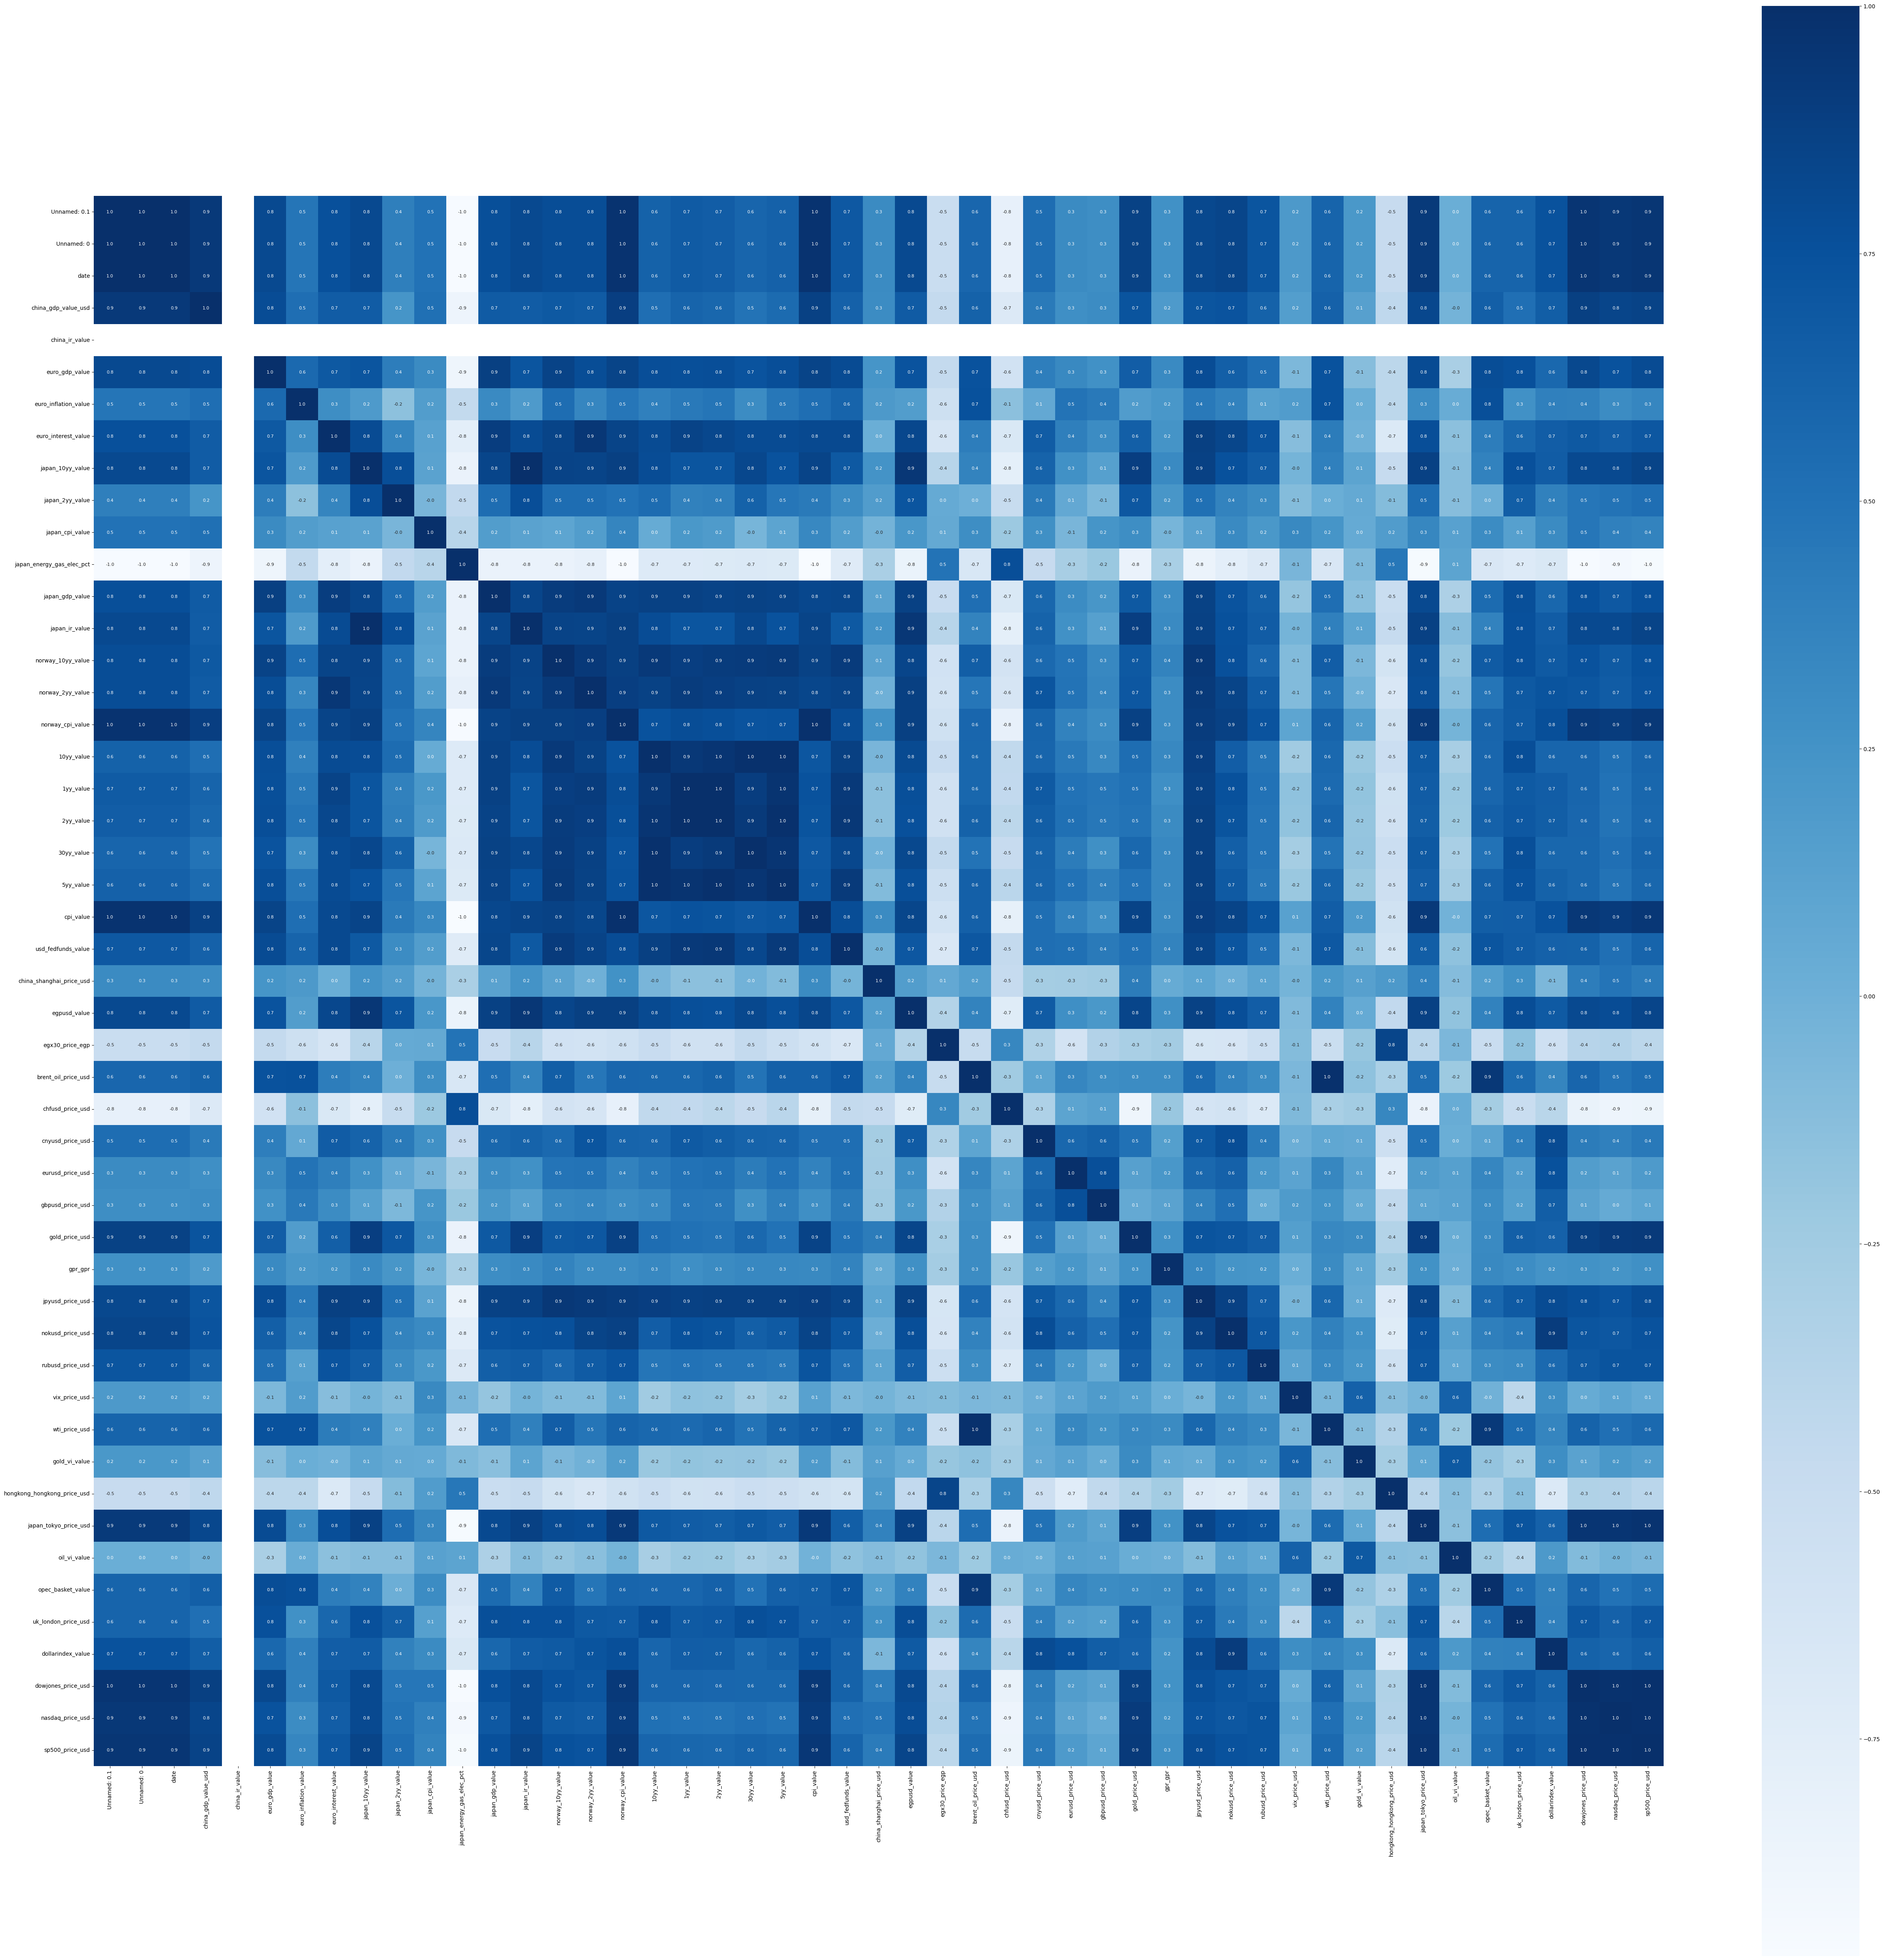

In [ ]:
#finding correlations
correlation = data.corr()

#heat map to understand correlation
plt.figure(figsize=(64,64))
sns.heatmap(correlation,cbar=True,square=True,fmt='.1f',annot=True,annot_kws={'size':8},cmap='Blues')

In [ ]:
#correlation values for gold prices
print(correlation['gold_price_usd'])

Unnamed: 0.1                   0.864479
Unnamed: 0                     0.864479
date                           0.864479
china_gdp_value_usd            0.726526
china_ir_value                      NaN
euro_gdp_value                 0.660519
euro_inflation_value           0.175111
euro_interest_value            0.639146
japan_10yy_value               0.885951
japan_2yy_value                0.705693
japan_cpi_value                0.287319
japan_energy_gas_elec_pct     -0.831804
japan_gdp_value                0.689888
japan_ir_value                 0.885951
norway_10yy_value              0.685870
norway_2yy_value               0.703211
norway_cpi_value               0.870756
10yy_value                     0.533677
1yy_value                      0.502544
2yy_value                      0.488618
30yy_value                     0.573882
5yy_value                      0.492353
cpi_value                      0.856353
usd_fedfunds_value             0.505511
china_shanghai_price_usd       0.428428


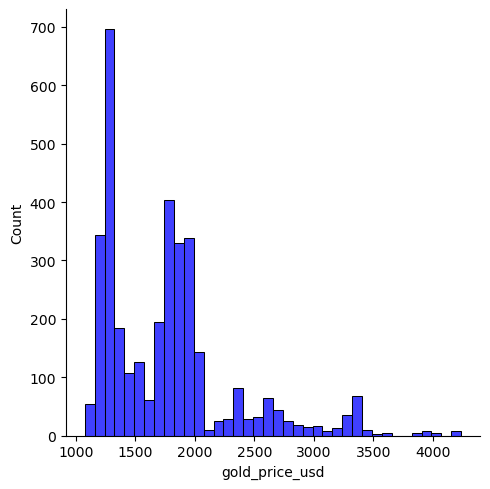

In [ ]:
#check the distribution of gold price
sns.displot(data['gold_price_usd'],color='blue')

Splitting data (features and target)

In [ ]:
X = data.drop(['date','gold_price_usd'],axis=1)
Y=data['gold_price_usd']

Train / Test Data

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size= 0.2,random_state=2)

model train

In [ ]:
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
tscv = TimeSeriesSplit(n_splits=5)


objective = "reg:squarederror"   # baseline

base_model = xgb.XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    verbosity=0
)

param_grid = {
    "n_estimators": [500, 1000, 1500],
    "learning_rate": [0.005, 0.01, 0.02],
    "max_depth": [4, 5, 6, 7],
    "min_child_weight": [1, 3, 5],
    "subsample": [0.6, 0.7, 0.8],
    "colsample_bytree": [0.6, 0.7, 0.8],
    "gamma": [0, 0.1, 0.2],
    "reg_alpha": [0, 0.1, 0.5],
    "reg_lambda": [1, 1.5, 2]
}

search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_grid,
    n_iter=30,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    verbose=1,
    n_jobs=-1
)

search.fit(X_train, Y_train)

regressor = xgb.XGBRegressor(
    **search.best_params_,
    objective="reg:squarederror",
    random_state=42,
    verbosity=0,
    early_stopping_rounds=50   # ✅ moved here
)

regressor.fit(
    X_train, Y_train,
    eval_set=[(X_test, Y_test)],
    verbose=False
)


test_data_preds = regressor.predict(X_test)

from sklearn import metrics
import numpy as np

r2 = metrics.r2_score(Y_test, test_data_preds)
mae = metrics.mean_absolute_error(Y_test, test_data_preds)
rmse = np.sqrt(metrics.mean_squared_error(Y_test, test_data_preds))

print("R Squared Error :", r2)
print("MAE :", mae)
print("RMSE :", rmse)
direction_true = np.sign(Y_test.diff().fillna(0))
direction_pred = np.sign(pd.Series(test_data_preds).diff().fillna(0))

direction_acc = (direction_true == direction_pred).mean()

print("Direction Accuracy :", direction_acc)



Fitting 5 folds for each of 30 candidates, totalling 150 fits
R Squared Error : 0.998550594193334
MAE : 12.04591312037447
RMSE : 20.646038897233232


ValueError: Can only compare identically-labeled Series objects

In [ ]:
#training
regressor.fit(X_train,Y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [ ]:
#model eval
test_data_preds = regressor.predict(X_test)

In [ ]:
#squared error
error_score = metrics.r2_score(Y_test,test_data_preds)
print("R Squared Error :",error_score)

R Squared Error : 0.9986716763877331


In [ ]:
X_f_predict = f_predict_data.drop(['date', 'gold_price_usd'], axis=1)
f_preds = regressor.predict(X_f_predict)
f_results = f_predict_data.copy()
f_results['gold_predicted'] = f_preds


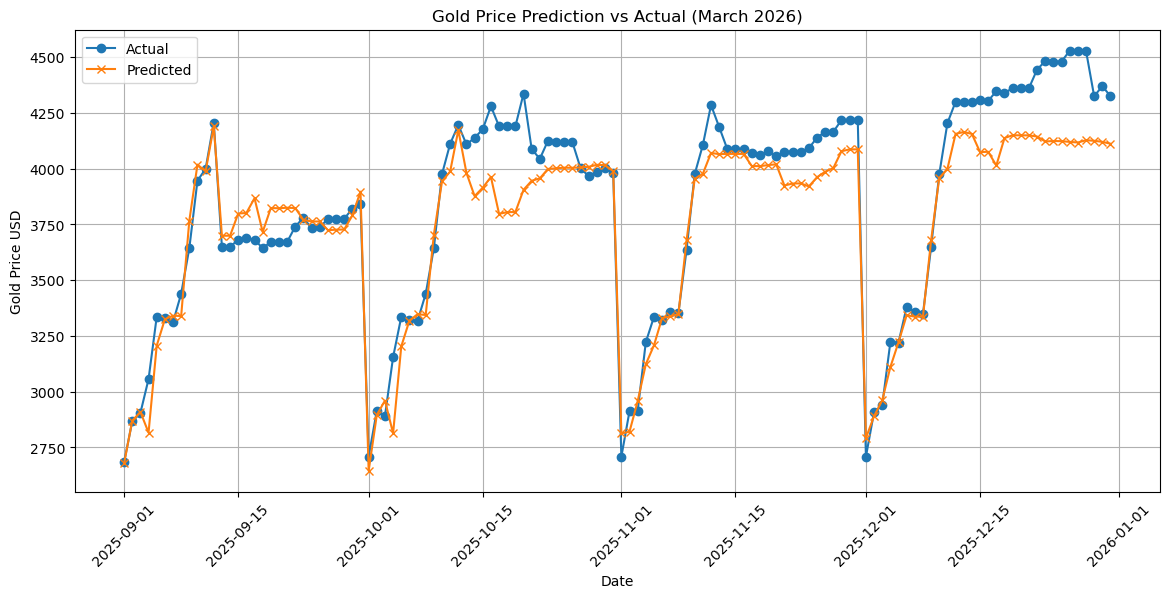

In [ ]:
#comparing
plt.figure(figsize=(14,6))
plt.plot(f_results['date'], f_results['gold_price_usd'], label='Actual', marker='o')
plt.plot(f_results['date'], f_results['gold_predicted'], label='Predicted', marker='x')
plt.title('Gold Price Prediction vs Actual (March 2026)')
plt.xlabel('Date')
plt.ylabel('Gold Price USD')
plt.legend()
plt.xticks(rotation=45)
plt.grid()
plt.show()